# Visual Ingredient Scanner — YOLO11s Training on Kaggle

This notebook:
1. Downloads the merged Roboflow dataset
2. Remaps classes to the master list
3. Caps over-represented classes (≤ 2 000 instances each)
4. Trains YOLO11s for 25 epochs
5. Evaluates mAP and plots training curves
6. Exports to TFLite INT8 + CoreML
7. Saves weights to `/kaggle/working/` — download from the **Output** tab

### Before running
1. Set accelerator to **GPU T4 x2**: `Settings → Accelerator → GPU T4 x2`
2. Enable internet: `Settings → Internet → On`
3. Add your Roboflow API key as a Kaggle secret: `Add-ons → Secrets → + Add secret` → name it `ROBOFLOW_API_KEY`
4. Fill in `WORKSPACE`, `PROJECT`, `VERSION` in **Cell 4**
5. Run all cells top to bottom

## 1 · Install dependencies

In [11]:
!pip install -q ultralytics roboflow pyyaml
print("Done.")

Done.


## 2 · Verify GPU

In [12]:
!nvidia-smi
import torch
assert torch.cuda.is_available(), "No GPU — enable GPU in Settings → Accelerator"
print(f"GPU: {torch.cuda.get_device_name(0)}")

Thu May 28 10:07:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 3 · Output directory

All files written to `/kaggle/working/` are saved automatically and available in the **Output** tab after the run.

In [13]:
import os
from pathlib import Path

WORKING_DIR = Path("/kaggle/working")
OUTPUT_DIR  = WORKING_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Working dir : {WORKING_DIR}")
print(f"Output dir  : {OUTPUT_DIR}")
print("Files saved here will appear in the Output tab.")

Working dir : /kaggle/working
Output dir  : /kaggle/working/outputs
Files saved here will appear in the Output tab.


## 4 · Dataset configuration

Fill in `WORKSPACE`, `PROJECT`, and `VERSION` with values from your Roboflow project URL.

In [ ]:
from kaggle_secrets import UserSecretsClient
secrets = UserSecretsClient()
ROBOFLOW_API_KEY = secrets.get_secret("ROBOFLOW_API_KEY")

# ── Your merged Roboflow dataset ──────────────────────────────────────────
WORKSPACE = "emma-w8nkb"                    # ← your workspace slug
PROJECT   = "visual-ingredient-scanner"     # ← your project slug
VERSION   = 1                               # ← version number on Roboflow

# ── Master class list — 86 classes ───────────────────────────────────────
MASTER_CLASSES = [
    # fruits (23)
    "apple","avocado","banana","blackberries","blueberries","cantaloupe",
    "cherry","coconut","fig","grapes","grapefruit","kiwi","lemon","lime",
    "mango","orange","peach","pear","pineapple","pomegranate","raspberries",
    "strawberries","watermelon",
    # vegetables (29)
    "artichoke","beet","broccoli","brussels_sprouts","cabbage","carrot",
    "cauliflower","celery","chili","corn","cucumber","eggplant","garlic",
    "ginger","green_beans","lettuce","mushrooms","okra","onion","peas",
    "pepper","potato","pumpkin","radish","spinach","sweet_potato","tomato",
    "turnip","zucchini",
    # proteins & dairy (12)
    "beef","butter","cheese","chicken","egg","fish","ham","heavy_cream",
    "pork","shrimp","tofu","yogurt",
    # pantry & packaged (22)
    "bread","canned_beans","cereal","chocolate","coffee","flour","honey",
    "hummus","jam","juice","mayonnaise","milk","nuts","oil","pasta","rice",
    "soda","sugar","tea","tomato_sauce","vinegar","water",
]
MASTER_IDX = {name: i for i, name in enumerate(MASTER_CLASSES)}

# ── Rename map (applied after lowercasing) ────────────────────────────────
RENAME_MAP = {
    # existing dataset renames
    "mayonaise":         "mayonnaise",
    "humus":             "hummus",
    "green beans":       "green_beans",
    "goat_cheese":       "cheese",
    "mozzarella cheese": "cheese",
    "olive_oil":         "oil",
    "bell pepper":       "pepper",
    "salad":             "lettuce",
    "common fig":        "fig",
    "vegetable marrow":  "zucchini",
    "brus capusta":      "brussels_sprouts",
    "cayliflower":       "cauliflower",
    "rediska":           "radish",
    "redka":             "radish",
    "fasol":             "canned_beans",  # Russian for legume beans
    "chilli":            "chili",
    "hot pepper":        "chili",
    "heavy cream":       "heavy_cream",
    "ground beef":       "beef",
    "grape":             "grapes",
    "strawberry":        "strawberries",
    # new dataset renames
    "beans":             "canned_beans",
    "pple":              "apple",       # truncated name in fresh produce dataset
    "capsicum":          "pepper",
    "beetroot":          "beet",
    "maize":             "corn",
    "melon":             "cantaloupe",
    "tomato sauce":      "tomato_sauce",
    "eggplant":          "eggplant",    # already correct, explicit for safety
}

# ── Classes to discard entirely ───────────────────────────────────────────
SKIP_SET = {
    "bittergourd", "chayote", "meat",
    "winter melon",
    "banana_pacche", "squash-patisson", "burger",
    "cake", "candy", "chips", "spices",
    "bitter_gourd", "bottle_gourd",     # new dataset exclusions
    "green_orange", "objects",
}

print(f"Master classes: {len(MASTER_CLASSES)}")

## 5 · Download dataset from Roboflow

In [ ]:
# ── Define all datasets to download ──────────────────────────────────────
DATASETS = [
    {"workspace": "emma-w8nkb", "project": "visual-ingredient-scanner",   "version": 1},
    {"workspace": "emma-w8nkb", "project": "vegetables-kacga-phjqz",      "version": None},  # auto-detect
    {"workspace": "emma-w8nkb", "project": "fruits-and-vegi-kudll",       "version": None},  # auto-detect
    {"workspace": "emma-w8nkb", "project": "grocery-items-obs1y-akkby",   "version": None},  # auto-detect
    {"workspace": "emma-w8nkb", "project": "my-first-project-q9pi7-rusns","version": None},  # auto-detect
]

import shutil
from roboflow import Roboflow
import yaml

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
RAW_DIRS = []

def download_best_version(project, preferred_version, dest, fmt="yolov11"):
    """Try preferred version first, then scan 1–10 for the first available one."""
    candidates = (
        [preferred_version] + [v for v in range(1, 11) if v != preferred_version]
        if preferred_version else list(range(1, 11))
    )
    for v in candidates:
        try:
            return project.version(v).download(fmt, location=dest), v
        except RuntimeError:
            continue
    raise RuntimeError(f"No downloadable version found (tried 1–10)")

for i, ds in enumerate(DATASETS):
    dest = str(WORKING_DIR / "datasets" / f"raw_{i}")
    shutil.rmtree(dest, ignore_errors=True)
    print(f"\nDownloading dataset {i}: {ds['workspace']}/{ds['project']} ...")
    project = rf.workspace(ds["workspace"]).project(ds["project"])
    dataset, used_version = download_best_version(project, ds["version"], dest)
    raw_dir = dataset.location
    # Find data.yaml in case Roboflow added a subfolder
    data_yaml_path = Path(raw_dir) / "data.yaml"
    if not data_yaml_path.exists():
        candidates = list(Path(raw_dir).rglob("data.yaml"))
        if candidates:
            raw_dir = str(candidates[0].parent)
    RAW_DIRS.append(raw_dir)
    cfg = yaml.safe_load(Path(raw_dir, "data.yaml").read_text())
    print(f"  → v{used_version}  {raw_dir}  ({cfg['nc']} classes)")

print(f"\nAll datasets downloaded: {len(RAW_DIRS)}")

*(Single-dataset download cell removed — multi-dataset download is handled by the cell above.)*

## 6 · Merge dataset with class remapping

Lowercases all class names, applies the rename map, skips excluded classes,
and remaps class indices in every label file to match the master list.

In [ ]:
import shutil

MERGED_DIR = WORKING_DIR / "datasets" / "merged"

def build_remap(source_names, rename_map, skip_set):
    remap = {}
    for i, name in enumerate(source_names):
        norm = name.lower().strip()
        if norm in skip_set:
            remap[i] = -1
            continue
        norm = rename_map.get(norm, norm)
        remap[i] = MASTER_IDX.get(norm, -1)
    return remap

def remap_label(src, dst, remap):
    lines_out = []
    for line in Path(src).read_text().strip().splitlines():
        if not line.strip():
            continue
        parts = line.split()
        master_idx = remap.get(int(parts[0]), -1)
        if master_idx >= 0:
            lines_out.append(f"{master_idx} " + " ".join(parts[1:]))
    Path(dst).write_text("\n".join(lines_out))

def merge_split(src_dir, split, remap, prefix):
    img_src = Path(src_dir) / split / "images"
    lbl_src = Path(src_dir) / split / "labels"
    img_dst = MERGED_DIR / split / "images"
    lbl_dst = MERGED_DIR / split / "labels"
    img_dst.mkdir(parents=True, exist_ok=True)
    lbl_dst.mkdir(parents=True, exist_ok=True)

    if not img_src.exists():
        return 0

    count = 0
    for img_path in img_src.iterdir():
        new_stem = f"ds{prefix}_{img_path.stem}"
        shutil.copy(img_path, img_dst / (new_stem + img_path.suffix))
        lbl_path = lbl_src / (img_path.stem + ".txt")
        if lbl_path.exists():
            remap_label(lbl_path, lbl_dst / (new_stem + ".txt"), remap)
        count += 1
    return count

# ── Run merge across all downloaded datasets ──────────────────────────────
total = {"train": 0, "valid": 0, "test": 0}

for i, raw_dir in enumerate(RAW_DIRS):
    data_yaml = yaml.safe_load(Path(raw_dir, "data.yaml").read_text())
    source_names = data_yaml["names"]
    remap = build_remap(source_names, RENAME_MAP, SKIP_SET)
    kept    = sum(1 for v in remap.values() if v >= 0)
    skipped = sum(1 for v in remap.values() if v < 0)
    print(f"\nDataset {i} — {raw_dir}")
    print(f"  source classes : {len(source_names)}")
    print(f"  kept           : {kept}")
    print(f"  skipped        : {skipped}")
    for split in ("train", "valid", "test"):
        total[split] += merge_split(raw_dir, split, remap, prefix=i)

merged_yaml = {
    "path":  str(MERGED_DIR),
    "train": "train/images",
    "val":   "valid/images",
    "test":  "test/images",
    "nc":    len(MASTER_CLASSES),
    "names": MASTER_CLASSES,
}
MERGED_YAML = str(MERGED_DIR / "data.yaml")
with open(MERGED_YAML, "w") as f:
    yaml.dump(merged_yaml, f, default_flow_style=False, sort_keys=False)

print("\n" + "=" * 50)
print(f"Merged dataset : {MERGED_DIR}")
print(f"  train  : {total['train']} images")
print(f"  valid  : {total['valid']} images")
print(f"  test   : {total['test']} images")
print(f"  total  : {sum(total.values())} images")
print(f"  classes: {len(MASTER_CLASSES)}")

## 7 · Verify merged dataset + cap over-represented classes

Classes with data: 83 / 83


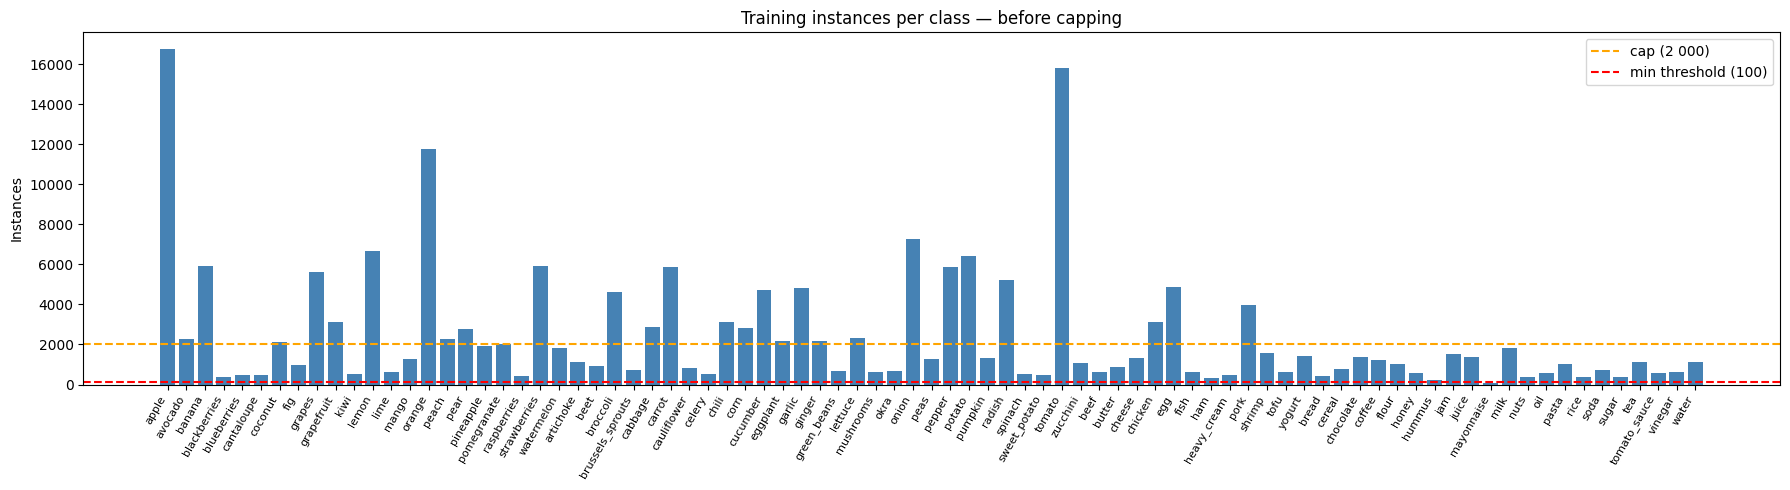


Class                      Instances
-------------------------------------
apple                          16745
tomato                         15807
orange                         11749
onion                           7272
lemon                           6657
potato                          6426
strawberries                    5936
banana                          5901
carrot                          5883
pepper                          5845
grapes                          5626
radish                          5231
egg                             4868
garlic                          4836
cucumber                        4724
broccoli                        4596
pork                            3951
chili                           3135
grapefruit                      3112
chicken                         3105
cabbage                         2876
corn                            2799
pear                            2762
lettuce                         2307
avocado                         2280

In [18]:
from collections import Counter
import matplotlib.pyplot as plt

label_dir = MERGED_DIR / "train" / "labels"

counter = Counter()
for lf in label_dir.glob("*.txt"):
    for line in lf.read_text().strip().splitlines():
        if line:
            counter[int(line.split()[0])] += 1

missing = [c for c in MASTER_CLASSES if MASTER_IDX[c] not in counter]
print(f"Classes with data: {len(counter)} / {len(MASTER_CLASSES)}")
if missing:
    print(f"Classes with NO training data: {missing}")

labels = [MASTER_CLASSES[i] for i in sorted(counter)]
counts = [counter[i] for i in sorted(counter)]

fig, ax = plt.subplots(figsize=(18, 5))
ax.bar(labels, counts, color="steelblue")
ax.axhline(2000, color="orange", linestyle="--", label="cap (2 000)")
ax.axhline(100,  color="red",    linestyle="--", label="min threshold (100)")
ax.set_title("Training instances per class — before capping")
ax.set_ylabel("Instances")
ax.legend()
plt.xticks(rotation=60, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "distribution_before_cap.png"), dpi=150)
plt.show()

print(f"\n{'Class':<25} {'Instances':>10}")
print("-" * 37)
for i in sorted(counter, key=lambda x: counter[x], reverse=True):
    print(f"{MASTER_CLASSES[i]:<25} {counter[i]:>10}")

In [19]:
import random
from collections import defaultdict, Counter

MAX_INSTANCES = 2000
label_dir = MERGED_DIR / "train" / "labels"
img_dir   = MERGED_DIR / "train" / "images"

# Build a map: file -> {cls: instance_count}
file_instances = {}
for lf in label_dir.glob("*.txt"):
    content = lf.read_text().strip()
    if not content:
        continue
    counts = Counter(
        int(line.split()[0])
        for line in content.splitlines() if line
    )
    file_instances[lf] = counts

class_data = defaultdict(list)
for lf, counts in file_instances.items():
    for cls, cnt in counts.items():
        class_data[cls].append((lf, cnt))

removed_files = set()

for cls in sorted(class_data,
                  key=lambda c: sum(cnt for _, cnt in class_data[c]),
                  reverse=True):

    available = [(lf, cnt) for lf, cnt in class_data[cls]
                 if lf not in removed_files]
    total_instances = sum(cnt for _, cnt in available)

    if total_instances <= MAX_INSTANCES:
        continue

    instances_to_remove = total_instances - MAX_INSTANCES

    solo_items  = [(lf, cnt) for lf, cnt in available
                   if len(file_instances[lf]) == 1]
    mixed_items = [(lf, cnt) for lf, cnt in available
                   if len(file_instances[lf]) > 1]

    random.shuffle(solo_items)
    random.shuffle(mixed_items)

    for lf, cnt in solo_items:
        if instances_to_remove <= 0:
            break
        removed_files.add(lf)
        instances_to_remove -= cnt

    if instances_to_remove > 0:
        for lf, cnt in mixed_items:
            if instances_to_remove <= 0:
                break
            removed_files.add(lf)
            instances_to_remove -= cnt

    removed_count = sum(cnt for lf, cnt in available if lf in removed_files)
    print(f"{MASTER_CLASSES[cls]:<25} {total_instances} → ~{total_instances - removed_count}")

for lf in removed_files:
    for ext in (".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"):
        img = img_dir / (lf.stem + ext)
        if img.exists():
            img.unlink()
            break
    lf.unlink(missing_ok=True)

print(f"\nDeleted {len(removed_files)} files.")
print(f"Training images remaining: {sum(1 for _ in label_dir.glob('*.txt'))}")

apple                     16745 → ~2000
tomato                    15655 → ~2000
orange                    11325 → ~1981
onion                     4999 → ~2000
lemon                     4866 → ~2000
potato                    5246 → ~1999
strawberries              5465 → ~1996
banana                    5119 → ~2000
carrot                    5113 → ~1999
pepper                    4779 → ~2000
grapes                    5577 → ~2000
radish                    5040 → ~2000
egg                       4424 → ~1988
garlic                    3654 → ~2000
cucumber                  4201 → ~2000
broccoli                  4376 → ~2000
pork                      2715 → ~1999
chili                     3109 → ~2000
chicken                   2422 → ~2000
cabbage                   2566 → ~1999
corn                      2475 → ~2000
pear                      2678 → ~1998
lettuce                   2139 → ~1999
avocado                   2231 → ~2000
peach                     2137 → ~1986
eggplant              

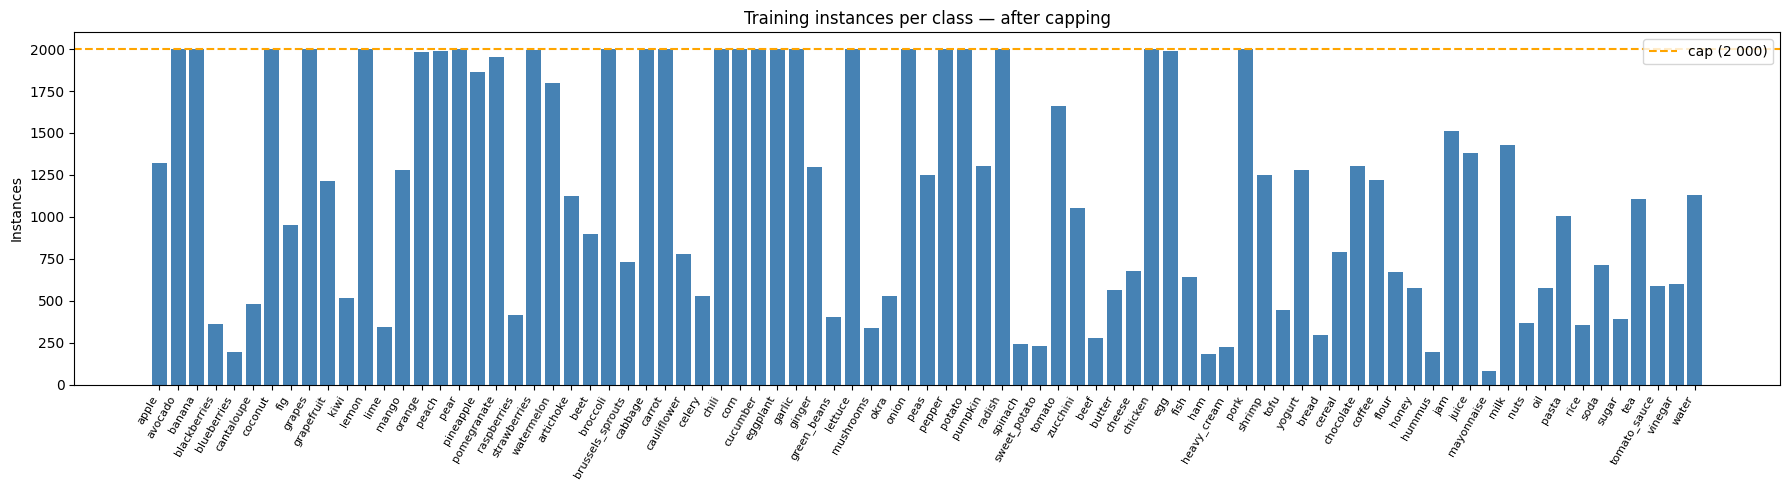

✅ All classes at or below 2000 instances — ready to train!
Total training images: 39379
Total instances      : 96793


In [20]:
# Verify final distribution
counter2 = Counter()
for lf in label_dir.glob("*.txt"):
    for line in lf.read_text().strip().splitlines():
        if line:
            counter2[int(line.split()[0])] += 1

labels2 = [MASTER_CLASSES[i] for i in sorted(counter2)]
counts2 = [counter2[i] for i in sorted(counter2)]

fig, ax = plt.subplots(figsize=(18, 5))
ax.bar(labels2, counts2, color="steelblue")
ax.axhline(2000, color="orange", linestyle="--", label="cap (2 000)")
ax.set_title("Training instances per class — after capping")
ax.set_ylabel("Instances")
ax.legend()
plt.xticks(rotation=60, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "distribution_after_cap.png"), dpi=150)
plt.show()

over = [MASTER_CLASSES[i] for i in counter2 if counter2[i] > 2000]
if over:
    print(f"⚠️  Still over 2000: {over}")
else:
    print("✅ All classes at or below 2000 instances — ready to train!")
print(f"Total training images: {sum(1 for _ in label_dir.glob('*.txt'))}")
print(f"Total instances      : {sum(counter2.values())}")

## 8 · Train YOLO11s

Expected time on Kaggle T4: **~4–5 hours** for 25 epochs.
Weights are saved after every epoch to `/kaggle/working/runs/food_detector/weights/`.

In [21]:
from ultralytics import YOLO

model = YOLO("yolo11s.pt")  # downloads base checkpoint automatically

results = model.train(
    data=MERGED_YAML,
    epochs=25,
    imgsz=416,
    batch=16,
    device=0,
    cos_lr=True,
    augment=True,
    workers=4,
    project=str(WORKING_DIR / "runs"),
    name="food_detector",
)

BEST_PT = str(WORKING_DIR / "runs" / "food_detector" / "weights" / "best.pt")
print(f"\nBest checkpoint: {BEST_PT}")

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/datasets/merged/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=food_detector-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tr

Exception in thread Thread-14 (_pin_memory_loop):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py", line 52, in _pin_memory_loop
    do_one_step()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py", line 28, in do_one_step
    r = in_queue.get(timeout=MP_STATUS_CHECK_INTERVAL)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/multiprocessing/reductions.py", line 540, in rebuild_storage_fd
    fd = df.detach()
         ^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/resource_

KeyboardInterrupt: 

In [ ]:
from pathlib import Path
import shutil

best = Path("/kaggle/working/runs/food_detector/weights/best.pt")
print(f"Exists: {best.exists()}, Size: {best.stat().st_size / 1e6:.1f} MB")

# Copy to working root so it's easy to find
shutil.copy(best, "/kaggle/working/food_detector.pt")
print("Copied to /kaggle/working/food_detector.pt")

In [ ]:
import shutil
shutil.copy(
    "/kaggle/working/runs/food_detector/weights/best.pt",
    "/kaggle/working/best.pt"
)

from IPython.display import FileLink
display(FileLink("best.pt"))

In [ ]:
from IPython.display import FileLink

shutil.copy("/kaggle/working/runs/food_detector/results.csv", "/kaggle/working/results.csv")
shutil.copy("/kaggle/working/runs/food_detector/results.png", "/kaggle/working/results.png")

display(FileLink("results.csv"))
display(FileLink("results.png"))

## 9 · Evaluate — preliminary metrics

Target: **mAP50-95 > 0.40**

In [ ]:
from pathlib import Path
BEST_PT    = "/kaggle/working/runs/food_detector/weights/best.pt"
MERGED_YAML = "/kaggle/working/datasets/merged/data.yaml"

In [ ]:
from ultralytics import YOLO

trained = YOLO(BEST_PT)
metrics = trained.val(data=MERGED_YAML, split="test", device=0)

print(f"\nmAP50-95 : {metrics.box.map:.3f}  (target > 0.40)")
print(f"mAP50    : {metrics.box.map50:.3f}")
print(f"mAP75    : {metrics.box.map75:.3f}")
print()
print("Per-class mAP50-95:")
for name, ap in zip(metrics.names.values(), metrics.box.maps):
    flag = "✅" if ap >= 0.40 else "⚠️ "
    print(f"  {flag} {name:<22} {ap:.3f}")

## 10 · Plot training curves

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results_csv = WORKING_DIR / "runs" / "food_detector" / "results.csv"
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(df["epoch"], df["train/box_loss"], label="train")
axes[0].plot(df["epoch"], df["val/box_loss"],   label="val")
axes[0].set_title("Box loss"); axes[0].legend()

axes[1].plot(df["epoch"], df["train/cls_loss"], label="train")
axes[1].plot(df["epoch"], df["val/cls_loss"],   label="val")
axes[1].set_title("Class loss"); axes[1].legend()

axes[2].plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
axes[2].plot(df["epoch"], df["metrics/mAP50(B)"],    label="mAP50")
axes[2].axhline(0.40, color="red", linestyle="--", label="target 0.40")
axes[2].set_title("mAP"); axes[2].legend()

plt.suptitle("Training curves — YOLO11s food detector")
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "training_curves.png"), dpi=150)
plt.show()
print("Saved training_curves.png")

## 11 · Export to TFLite (Android) and CoreML (iOS)

In [ ]:
trained.export(format="tflite", int8=True, imgsz=640, data=MERGED_YAML)
print("TFLite INT8 export done.")

In [ ]:
try:
    trained.export(format="coreml", imgsz=640)
    print("CoreML export done.")
except Exception as e:
    print(f"CoreML skipped (needs macOS): {e}")

## 12 · Copy outputs — download from the Output tab

All files are copied to `/kaggle/working/outputs/`.
Go to the **Output** tab (top right) to download them.

In [ ]:
import shutil

weights_dir = WORKING_DIR / "runs" / "food_detector" / "weights"

copy_map = {
    "food_detector.pt":      weights_dir / "best.pt",
    "food_detector_last.pt": weights_dir / "last.pt",
    "results.csv":           WORKING_DIR / "runs" / "food_detector" / "results.csv",
}

print("Files saved to Output tab:")
for dst_name, src in copy_map.items():
    if src.exists():
        shutil.copy(src, OUTPUT_DIR / dst_name)
        print(f"  ✅ {dst_name}")
    else:
        print(f"  ⚠️  {dst_name} not found at {src}")

for tflite in weights_dir.glob("*.tflite"):
    shutil.copy(tflite, OUTPUT_DIR / tflite.name)
    print(f"  ✅ {tflite.name}")

print(f"\n→ Go to the Output tab to download your files.")
print(f"→ Place food_detector.pt in models/yolo/food_detector.pt in the repo.")

## 13 · Quick inference test

In [ ]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image as PILImage

val_img_dir = MERGED_DIR / "valid" / "images"
test_imgs = random.sample(sorted(val_img_dir.glob("*")), min(4, len(list(val_img_dir.glob("*")))))

fig, axes = plt.subplots(1, len(test_imgs), figsize=(16, 5))
if len(test_imgs) == 1:
    axes = [axes]

for ax, img_path in zip(axes, test_imgs):
    preds = trained(str(img_path), conf=0.25, verbose=False)[0]
    img = PILImage.open(img_path)
    ax.imshow(img)
    for box in preds.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        cls  = preds.names[int(box.cls)]
        conf = float(box.conf)
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                   linewidth=2, edgecolor="lime", facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, y1-5, f"{cls} {conf:.2f}", color="lime", fontsize=8)
    ax.axis("off")

plt.suptitle("Inference on validation images", fontsize=14)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "inference_samples.png"), dpi=150)
plt.show()
print("Saved inference_samples.png")

## Summary

After running this notebook, go to the **Output** tab to download:

| File | Description |
|---|---|
| `outputs/food_detector.pt` | Fine-tuned YOLO11s checkpoint (best epoch) |
| `outputs/food_detector_last.pt` | Last epoch checkpoint (backup) |
| `outputs/food_detector_int8.tflite` | INT8 TFLite export for Android |
| `outputs/results.csv` | Per-epoch training metrics |
| `outputs/training_curves.png` | Loss + mAP plots |
| `outputs/inference_samples.png` | Sample detection results |

### Next steps
1. Download `food_detector.pt` → place at `models/yolo/food_detector.pt` in the repo
2. Download `food_detector_int8.tflite` → place at `models/yolo/food_detector.tflite`
3. Create `.env` with `GEMINI_API_KEY=your_key`
4. Run the Gradio demo: `python prototype/app.py`
5. Add the mAP number to `docs/phase2_report.md` Section 6